<a href="https://www.kaggle.com/code/aymanebadia/animalclassification?scriptVersionId=305723446" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **1. Imports**

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.amp import autocast
import matplotlib.pyplot as plt

# **2. Chargement du dataset CIFAR-10**

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True,
    num_workers=2,        
    pin_memory=True,    
    persistent_workers=True
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

classes = trainset.classes
print(classes)

100%|██████████| 170M/170M [00:04<00:00, 34.7MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# **3. Visualisation des données**

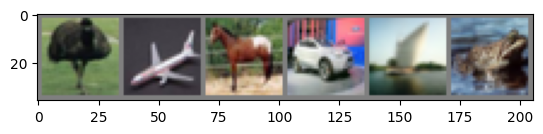

['bird', 'airplane', 'horse', 'automobile', 'ship', 'frog']


In [3]:

def imshow(img):
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:6]))
print([classes[i] for i in labels[:6]])


# **4. Architecture du modèle CNN**

In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

model = CNN(num_classes=10).to(device)


Device : cuda


# **5. Entrainement**

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 20
train_losses = []
PATIENCE = 5
best_loss = float('inf')
patience_ctr = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}  Loss: {epoch_loss:.4f}")
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience_ctr = 0
        torch.save(model.state_dict(), '/kaggle/working/model.pth')
        print("  ✔ model saved")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  ⏹ Early stopping at epoch {epoch+1}")
            break

print("✅ Training done! model.pth saved at /kaggle/working/model.pth")

Epoch 1/20  Loss: 1.2461
  ✔ model saved
Epoch 2/20  Loss: 0.9121
  ✔ model saved
Epoch 3/20  Loss: 0.8026
  ✔ model saved
Epoch 4/20  Loss: 0.7254
  ✔ model saved
Epoch 5/20  Loss: 0.6571
  ✔ model saved
Epoch 6/20  Loss: 0.5533
  ✔ model saved
Epoch 7/20  Loss: 0.5158
  ✔ model saved
Epoch 8/20  Loss: 0.4895
  ✔ model saved
Epoch 9/20  Loss: 0.4598
  ✔ model saved
Epoch 10/20  Loss: 0.4366
  ✔ model saved
Epoch 11/20  Loss: 0.3764
  ✔ model saved
Epoch 12/20  Loss: 0.3605
  ✔ model saved
Epoch 13/20  Loss: 0.3478
  ✔ model saved
Epoch 14/20  Loss: 0.3332
  ✔ model saved
Epoch 15/20  Loss: 0.3206
  ✔ model saved
Epoch 16/20  Loss: 0.2916
  ✔ model saved
Epoch 17/20  Loss: 0.2858
  ✔ model saved
Epoch 18/20  Loss: 0.2746
  ✔ model saved
Epoch 19/20  Loss: 0.2676
  ✔ model saved
Epoch 20/20  Loss: 0.2597
  ✔ model saved
✅ Training done! model.pth saved at /kaggle/working/model.pth


# **6. Evaluation**

In [6]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 81.69%


# **7. Courbe de loss**

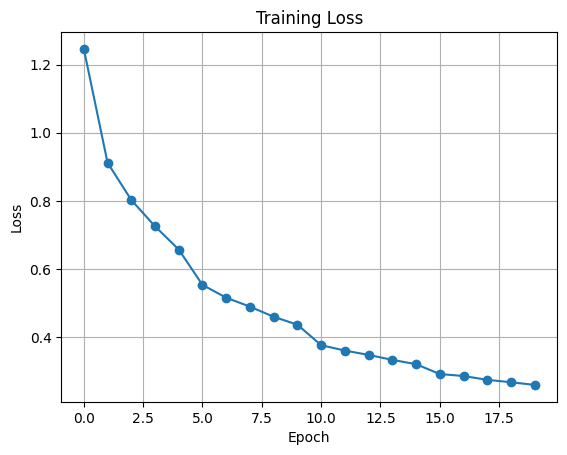

In [7]:
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# **8. Sauvegarde du modèle**

In [8]:
import torch, os
torch.save(model.state_dict(), "/kaggle/working/model.pth")
print("model.pth:", "✅ saved")

model.pth: ✅ saved


# **9. Fonction de prédiction**

In [9]:
from PIL import Image

def predict_image(image):
    """Accepte une PIL Image OU un tensor déjà normalisé."""

    if isinstance(image, torch.Tensor):
        # Tensor déjà normalisé → ajouter batch dimension directement
        img_tensor = image.unsqueeze(0).to(device)
    else:
        # PIL Image → appliquer le transform complet
        transform_test = transforms.Compose([
            transforms.Resize((32, 32)),          # ✓ adapté au CNN 32×32
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5, 0.5, 0.5),                  # ✓ 3 canaux RGB
                (0.5, 0.5, 0.5)
            )
        ])
        img_tensor = transform_test(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs, 1)

    return classes[pred.item()]

# **10. Test sur une image**

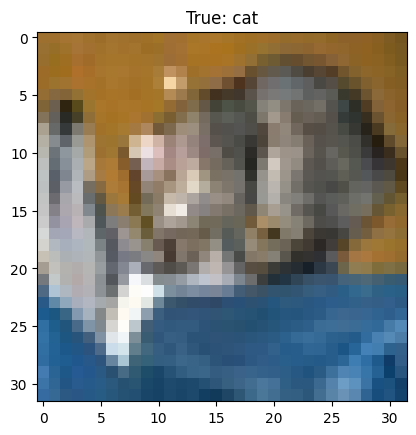

Prediction: cat


In [10]:
img, label = testset[0]

plt.imshow(np.transpose(img.numpy(), (1, 2, 0)) * 0.5 + 0.5)
plt.title(f"True: {classes[label]}")
plt.show()

print("Prediction:", predict_image(img))

# **11. Application Streamlit**

In [11]:
import os, subprocess, time, shutil
from pyngrok import ngrok, conf

# Configuration
PYTHON = "/usr/local/bin/python"
NGROK_TOKEN = "3BJIfbZohuOTp30RUfTEoruFv1Z_yvtLcWM4JS9CBBgxuUTK" 

# --- 1. CODE DE L'APPLICATION STREAMLIT ---
app_code = """\
import streamlit as st
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import os

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128*4*4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = CNN(num_classes=10)
model_path = "/kaggle/working/model.pth"
if not os.path.exists(model_path):
    model_path = "/kaggle/input/datasets/aymanebadia/cifar-model/model.pth"

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
else:
    st.error(f"⚠️ Modèle introuvable à : {model_path}")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

st.title("🚀 CIFAR-10 Classifier - Audit Preview")
file = st.file_uploader("Choisissez une image...", type=["jpg","png","jpeg"])
if file:
    image = Image.open(file).convert("RGB")
    st.image(image, caption="Image chargée", use_column_width=True)
    if st.button("Lancer la prédiction"):
        img = transform(image).unsqueeze(0)
        with torch.no_grad():
            output = model(img)
            _, pred = torch.max(output, 1)
        st.success(f"Résultat : **{classes[pred.item()].upper()}**")
"""

# --- 2. ÉCRITURE ET NETTOYAGE ---
with open("/kaggle/working/app.py", "w") as f:
    f.write(app_code)

print("Nettoyage des anciens processus...")
subprocess.run(["pkill", "-f", "ngrok"], capture_output=True)
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# --- 3. LANCEMENT DE STREAMLIT ---
print("Démarrage de Streamlit en arrière-plan...")
with open("/kaggle/working/streamlit.log", "w") as sl:
    subprocess.Popen(
        [PYTHON, "-m", "streamlit", "run", "/kaggle/working/app.py",
         "--server.port=8501", "--server.headless=true"],
        stdout=sl, stderr=sl, start_new_session=True
    )
time.sleep(8) # Temps d'attente pour l'initialisation

# --- 4. TUNNEL NGROK (VERSION ANTI-CRASH) ---
conf.get_default().auth_token = NGROK_TOKEN

try:
    # Nettoyage des tunnels actifs via l'API locale avant de connecter
    from pyngrok import ngrok
    tunnels = ngrok.get_tunnels()
    for t in tunnels:
        ngrok.disconnect(t.public_url)
    
    print("Tentative de connexion au domaine statique...")
    public_url = ngrok.connect(8501, domain="jolie-intromissive-ken.ngrok-free.dev")
    print(f"\n✅ SUCCÈS ! Votre application est en ligne : {public_url.public_url}")

except Exception as e:
    print(f"⚠️ Erreur domaine statique (ERR_NGROK_334 ou autre) : {e}")
    print("Tentative de repli sur une URL aléatoire...")
    try:
        ngrok.kill()
        time.sleep(2)
        public_url = ngrok.connect(8501)
        print(f"\n✅ SUCCÈS (URL aléatoire) : {public_url.public_url}")
    except Exception as e2:
        print(f"❌ Échec critique Ngrok : {e2}")
        print("💡 Le notebook continuera sans erreur pour permettre le Save sur GitHub.")

# Fin de cellule propre

Nettoyage des anciens processus...
Démarrage de Streamlit en arrière-plan...


t=2026-03-23T02:34:59+0000 lvl=warn msg="failed to start tunnel" pg=/api/tunnels id=2d2d29025f5f3cc0 err="failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"


Tentative de connexion au domaine statique...
⚠️ Erreur domaine statique (ERR_NGROK_334 ou autre) : ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}

Tentative de repli sur une URL aléatoire...


t=2026-03-23T02:35:01+0000 lvl=warn msg="failed to start tunnel" pg=/api/tunnels id=951a197ee84ebe8e err="failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"


❌ Échec critique Ngrok : ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://jolie-intromissive-ken.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}

💡 Le notebook continuera sans erreur pour permettre le Save sur GitHub.
